# MCAP Dataset Visualizer

Inspect a single `.mcap` recording: list all topics, decode H.264 camera streams, and plot scalar topic time-series (joint states, IMU, tactile).

Edit `MCAP_PATH` below and run all cells.

In [23]:
MCAP_PATH = "/data/kding/Openpi_RL/mcap_data/fold_cloth_umi/recording_20260417_034537.mcap"

# Decode every Nth video packet (still decode all packets for H.264 continuity, but keep only 1/N frames in memory).
VIDEO_KEEP_STRIDE = 1

# Downsample decoded frames to this width (keeps aspect ratio). Lower = less RAM.
RESIZE_WIDTH = 320

import os, sys, struct, time, warnings, contextlib
from pathlib import Path
from collections import defaultdict

import numpy as np
import matplotlib.pyplot as plt
import cv2

from mcap.reader import make_reader
import av

warnings.filterwarnings('ignore')
av.logging.set_level(av.logging.PANIC)  # suppress ffmpeg warnings ("non-existing PPS 0", "no frame!", etc.)

@contextlib.contextmanager
def _suppress_stderr():
    """Also suppress the C-level stderr ffmpeg writes to when it doesn't respect log level."""
    fd = sys.stderr.fileno() if hasattr(sys.stderr, 'fileno') else None
    if fd is None:
        yield
        return
    with open(os.devnull, 'w') as devnull:
        old = os.dup(fd)
        try:
            os.dup2(devnull.fileno(), fd)
            yield
        finally:
            os.dup2(old, fd)
            os.close(old)

try:
    import ipywidgets as widgets
    from IPython.display import display
    HAS_WIDGETS = True
except Exception:
    HAS_WIDGETS = False

assert os.path.isfile(MCAP_PATH), f"missing: {MCAP_PATH}"
print(f"file: {MCAP_PATH}")
print(f"size: {os.path.getsize(MCAP_PATH)/1e6:.1f} MB")

file: /data/kding/Openpi_RL/mcap_data/fold_cloth_umi/recording_20260417_034537.mcap
size: 389.5 MB


## CDR parsers

The off-the-shelf `mcap_ros2` decoder mis-parses some messages in this file (ROS2 CDR alignment is measured from the start of the payload, *not* from the encapsulation header — some versions of the helper library get this wrong for `geometry_msgs/Vector3` nested inside `sensor_msgs/Imu`). Instead we decode the handful of ROS2 messages we care about with small hand-rolled CDR readers.

In [24]:
BASE = 4  # CDR alignment base: right after the 4-byte encapsulation header

def _align(o, sz):
    return o + (-(o - BASE)) % sz

def _read_str(raw, o, endian='<'):
    o = _align(o, 4)
    ln = struct.unpack_from(endian + 'I', raw, o)[0]
    o += 4
    s = raw[o:o+ln-1].decode('utf-8', errors='replace') if ln > 0 else ''
    return s, o + ln

def _read_header(raw, o, endian='<'):
    sec, ns = struct.unpack_from(endian + 'iI', raw, o); o += 8
    fid, o = _read_str(raw, o, endian)
    return sec + ns*1e-9, fid, o

def _endian(raw):
    return '<' if raw[1] == 1 else '>'

def parse_imu(raw):
    e = _endian(raw); o = 4
    ts, fid, o = _read_header(raw, o, e)
    o = _align(o, 8)
    quat = struct.unpack_from(e + 'dddd', raw, o); o += 32
    ocov = struct.unpack_from(e + 'd'*9, raw, o); o += 72
    ang  = struct.unpack_from(e + 'ddd', raw, o);  o += 24
    acov = struct.unpack_from(e + 'd'*9, raw, o);  o += 72
    lin  = struct.unpack_from(e + 'ddd', raw, o);  o += 24
    lcov = struct.unpack_from(e + 'd'*9, raw, o);  o += 72
    return dict(ts=ts, frame_id=fid, orient=quat, ang_vel=ang, lin_acc=lin,
                orient_cov=ocov, ang_cov=acov, lin_cov=lcov)

def parse_joint_state(raw):
    e = _endian(raw); o = 4
    ts, fid, o = _read_header(raw, o, e)
    def _seq_str():
        nonlocal o
        o = _align(o, 4)
        n = struct.unpack_from(e + 'I', raw, o)[0]; o += 4
        out = []
        for _ in range(n):
            s, o2 = _read_str(raw, o, e); o = o2
            out.append(s)
        return out
    def _seq_f64():
        nonlocal o
        o = _align(o, 4)
        n = struct.unpack_from(e + 'I', raw, o)[0]; o += 4
        if n == 0: return []
        o = _align(o, 8)
        out = list(struct.unpack_from(e + 'd'*n, raw, o)); o += 8*n
        return out
    names = _seq_str()
    pos = _seq_f64()
    vel = _seq_f64()
    eff = _seq_f64()
    return dict(ts=ts, frame_id=fid, name=names, position=pos, velocity=vel, effort=eff)

def parse_compressed_video(raw):
    e = _endian(raw); o = 4
    sec, ns = struct.unpack_from(e + 'iI', raw, o); o += 8
    fid, o = _read_str(raw, o, e)
    o = _align(o, 4)
    al = struct.unpack_from(e + 'I', raw, o)[0]; o += 4
    vbuf = bytes(raw[o:o+al]); o += al
    fmt, _ = _read_str(raw, o, e)
    return sec + ns*1e-9, fid, vbuf, fmt

# ROS2 PointField type code -> numpy dtype char
_PCD_DTYPE = {1:'i1', 2:'u1', 3:'i2', 4:'u2', 5:'i4', 6:'u4', 7:'f4', 8:'f8'}

def parse_pointcloud_full(raw):
    """Decode a sensor_msgs/PointCloud2 including the point buffer."""
    e = _endian(raw); o = 4
    ts, fid, o = _read_header(raw, o, e)
    o = _align(o, 4)
    height = struct.unpack_from(e + 'I', raw, o)[0]; o += 4
    width  = struct.unpack_from(e + 'I', raw, o)[0]; o += 4
    n_fields = struct.unpack_from(e + 'I', raw, o)[0]; o += 4
    fields = []
    for _ in range(n_fields):
        fname, o = _read_str(raw, o, e)
        o = _align(o, 4)
        foff = struct.unpack_from(e + 'I', raw, o)[0]; o += 4
        fdt  = struct.unpack_from(e + 'B', raw, o)[0]; o += 1
        o = _align(o, 4)
        fcnt = struct.unpack_from(e + 'I', raw, o)[0]; o += 4
        fields.append({'name': fname, 'offset': foff, 'dt': fdt, 'count': fcnt})
    is_be = struct.unpack_from(e + 'B', raw, o)[0]; o += 1
    o = _align(o, 4)
    point_step = struct.unpack_from(e + 'I', raw, o)[0]; o += 4
    row_step   = struct.unpack_from(e + 'I', raw, o)[0]; o += 4
    o = _align(o, 4)
    _seq_len = struct.unpack_from(e + 'I', raw, o)[0]; o += 4

    n_points = width * height
    bo = '>' if is_be else '<'
    np_dtype = np.dtype({
        'names':   [f['name'] for f in fields],
        'formats': [
            (bo + _PCD_DTYPE[f['dt']], f['count']) if f['count'] > 1
            else bo + _PCD_DTYPE[f['dt']]
            for f in fields
        ],
        'offsets': [f['offset'] for f in fields],
        'itemsize': point_step,
    })
    buf = bytes(raw[o:o + n_points * point_step])
    pts = np.frombuffer(buf, dtype=np_dtype, count=n_points)
    return {'ts': ts, 'frame_id': fid, 'width': width, 'height': height,
            'n_points': n_points, 'fields': fields,
            'point_step': point_step, 'points': pts}

# Keep backwards-compatible name returning a metadata-only view.
def parse_pointcloud_meta(raw):
    d = parse_pointcloud_full(raw)
    return {k: d[k] for k in ('ts', 'frame_id', 'width', 'height', 'n_points', 'fields')}

print("CDR parsers ready")

CDR parsers ready


## File summary

In [26]:
with open(MCAP_PATH, 'rb') as f:
    reader = make_reader(f)
    summary = reader.get_summary()

stats = summary.statistics
dur = (stats.message_end_time - stats.message_start_time) / 1e9
print(f"messages: {stats.message_count}   duration: {dur:.2f} s\n")

chs = []
for cid, ch in summary.channels.items():
    sch = summary.schemas.get(ch.schema_id)
    cnt = stats.channel_message_counts.get(cid, 0)
    chs.append((ch.topic, sch.name if sch else '?', cnt, cnt/dur if dur>0 else 0))
chs.sort()

print(f"{'topic':<60} {'schema':<32} {'count':>8} {'Hz':>6}")
print('-'*110)
for t, s, c, hz in chs:
    print(f"{t:<60} {s:<32} {c:>8} {hz:>6.1f}")

messages: 43150   duration: 50.61 s

topic                                                        schema                              count     Hz
--------------------------------------------------------------------------------------------------------------
/robot/camera/head/left/camera_info                          sensor_msgs/CameraInfo                 52    1.0
/robot/camera/head/left/video_encoded                        foxglove_msgs/CompressedVideo         955   18.9
/robot/camera/head/right/camera_info                         sensor_msgs/CameraInfo                 52    1.0
/robot/camera/head/right/video_encoded                       foxglove_msgs/CompressedVideo         955   18.9
/robot/camera/left_wrist/left/camera_info                    sensor_msgs/CameraInfo                 52    1.0
/robot/camera/left_wrist/left/video_encoded                  foxglove_msgs/CompressedVideo         955   18.9
/robot/camera/left_wrist/right/camera_info                   sensor_msgs/CameraInf

## Decode camera streams

Each `*_encoded` topic carries one H.264 frame per message. We decode them sequentially with PyAV and keep a downsampled copy in memory.

In [4]:
video_topics = sorted([t for t, s, _, c in chs if 'CompressedVideo' in s and c > 0])
print(f"{len(video_topics)} video streams:")
for t in video_topics:
    print(' ', t)

def _resize(img, width):
    if width is None or width <= 0 or img.shape[1] <= width:
        return img
    h = int(round(img.shape[0] * width / img.shape[1]))
    return cv2.resize(img, (width, h), interpolation=cv2.INTER_AREA)

def decode_stream(path, topic, stride=1, width=RESIZE_WIDTH):
    """Return (timestamps[ndarray], frames[list of rgb uint8 arrays])."""
    timestamps, frames = [], []
    with open(path, 'rb') as f, _suppress_stderr():
        reader = make_reader(f)
        codec = av.CodecContext.create('h264', 'r')
        kept = 0
        last_ts = 0.0
        for _, _, msg in reader.iter_messages(topics=[topic]):
            ts, _, vdata, _fmt = parse_compressed_video(msg.data)
            last_ts = ts
            try:
                decoded = list(codec.decode(av.Packet(vdata)))
            except av.error.InvalidDataError:
                decoded = []
            for fr in decoded:
                kept += 1
                if (kept - 1) % stride != 0:
                    continue
                img = fr.to_ndarray(format='rgb24')
                frames.append(_resize(img, width))
                timestamps.append(ts)
        for fr in codec.decode(None):
            kept += 1
            if (kept - 1) % stride != 0:
                continue
            img = fr.to_ndarray(format='rgb24')
            frames.append(_resize(img, width))
            timestamps.append(last_ts)
    return np.array(timestamps), frames

streams = {}
t0 = time.time()
for t in video_topics:
    ts, fr = decode_stream(MCAP_PATH, t, VIDEO_KEEP_STRIDE, RESIZE_WIDTH)
    streams[t] = (ts, fr)
    print(f"  {t}: {len(fr)} frames @ {fr[0].shape if fr else None}")
print(f"decoded all cameras in {time.time()-t0:.1f}s")

6 video streams:
  /robot/camera/head/left/video_encoded
  /robot/camera/head/right/video_encoded
  /robot/camera/left_wrist/left/video_encoded
  /robot/camera/left_wrist/right/video_encoded
  /robot/camera/right_wrist/left/video_encoded
  /robot/camera/right_wrist/right/video_encoded
  /robot/camera/head/left/video_encoded: 931 frames @ (272, 320, 3)
  /robot/camera/head/right/video_encoded: 927 frames @ (272, 320, 3)
  /robot/camera/left_wrist/left/video_encoded: 929 frames @ (272, 320, 3)
  /robot/camera/left_wrist/right/video_encoded: 930 frames @ (272, 320, 3)
  /robot/camera/right_wrist/left/video_encoded: 950 frames @ (272, 320, 3)
  /robot/camera/right_wrist/right/video_encoded: 948 frames @ (272, 320, 3)
decoded all cameras in 69.0s


### Sample grid — uniform time points

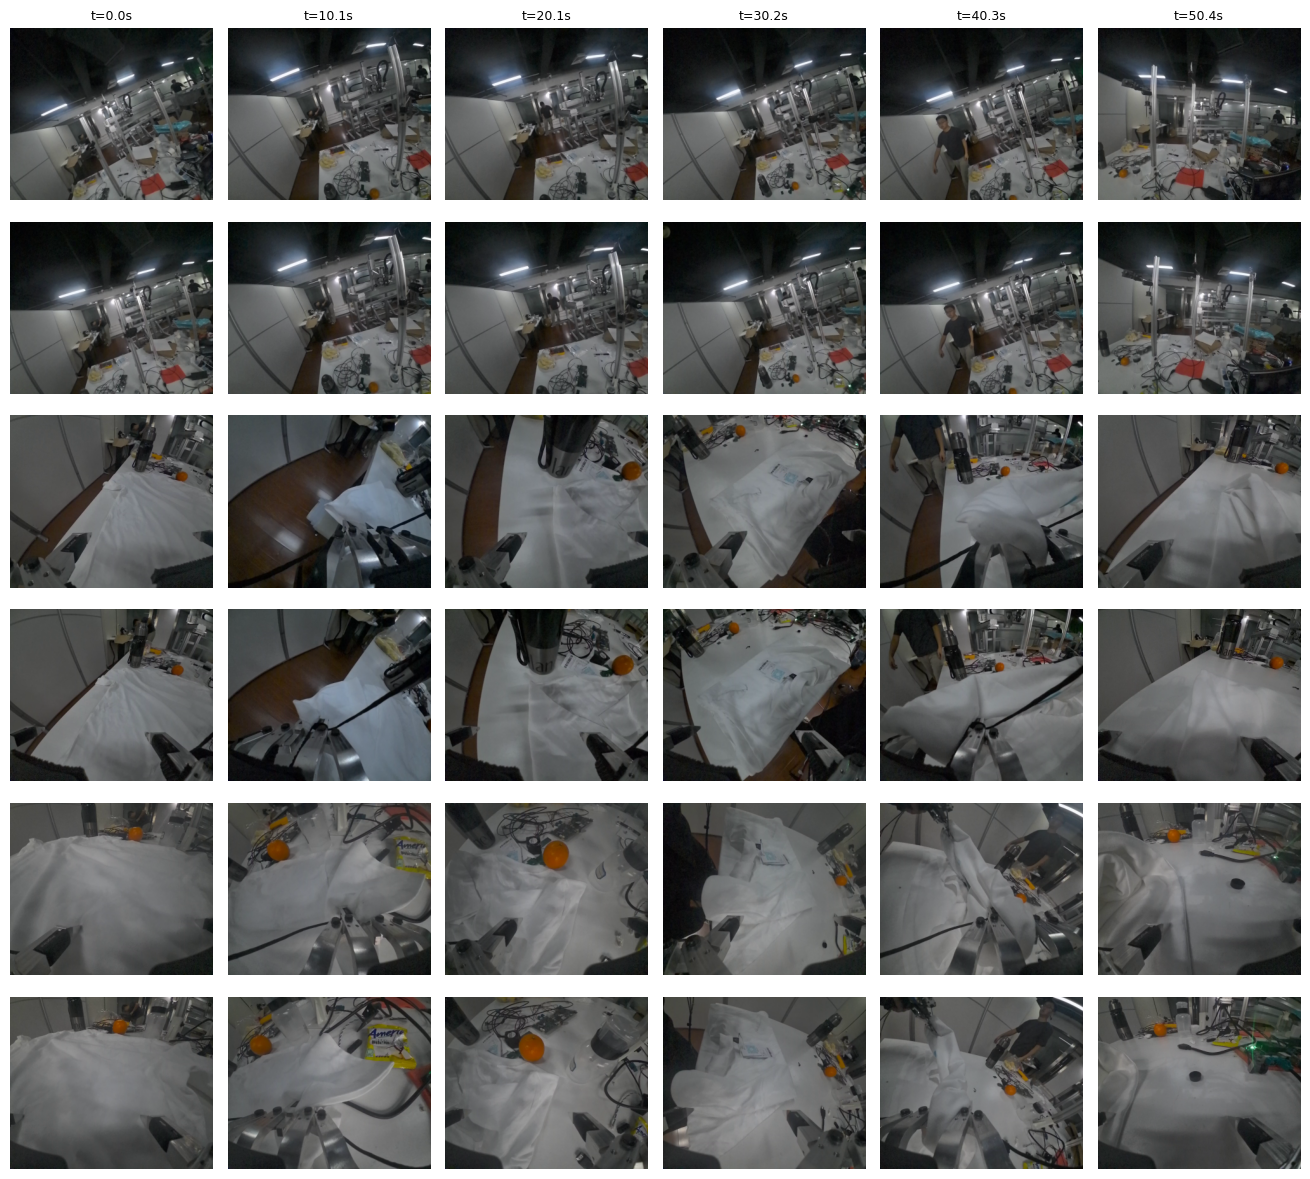

In [5]:
def _short(topic):
    # /robot/camera/head/left/video_encoded -> head/left
    p = topic.strip('/').split('/')
    try:
        i = p.index('camera')
        return '/'.join(p[i+1:i+3])
    except ValueError:
        return topic

N_SAMPLES = 6
fig, axes = plt.subplots(len(video_topics), N_SAMPLES,
                         figsize=(2.2*N_SAMPLES, 2.0*len(video_topics)))
if len(video_topics) == 1:
    axes = axes[None, :]

t_start = min(ts[0] for ts, _ in streams.values())
t_end   = max(ts[-1] for ts, _ in streams.values())
sample_ts = np.linspace(t_start, t_end, N_SAMPLES)

for r, topic in enumerate(video_topics):
    ts, frames = streams[topic]
    for c, target in enumerate(sample_ts):
        k = int(np.argmin(np.abs(ts - target)))
        axes[r, c].imshow(frames[k])
        axes[r, c].axis('off')
        if r == 0:
            axes[r, c].set_title(f't={target-t_start:.1f}s', fontsize=9)
        if c == 0:
            axes[r, c].set_ylabel(_short(topic), fontsize=9, rotation=0, ha='right', va='center')
plt.tight_layout()
plt.show()

### Interactive slider

Drag the slider to scrub through the recording. All cameras are aligned to the nearest frame at each timestamp.

FloatSlider(value=1776397536.7838688, description='time [s]', layout=Layout(width='80%'), max=1776397587.13465…

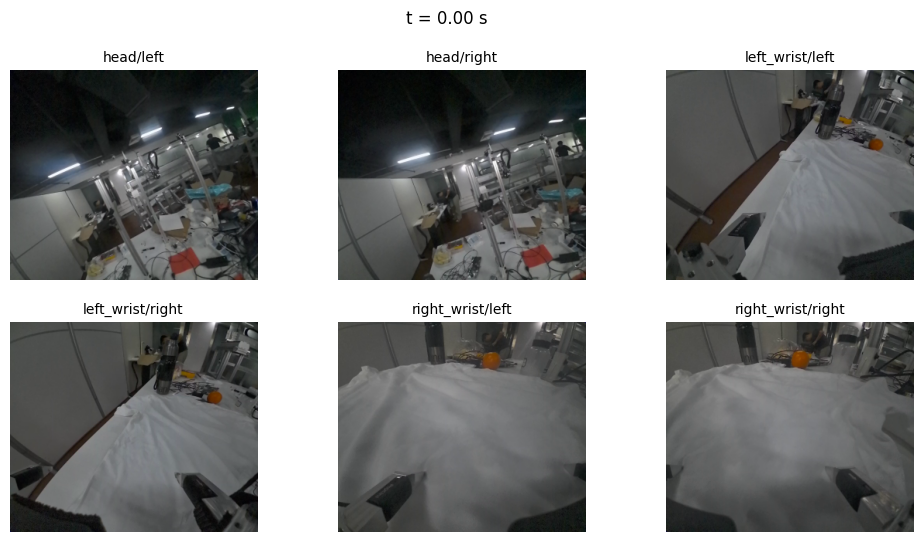

In [6]:
if HAS_WIDGETS and video_topics:
    cols = min(3, len(video_topics))
    rows = int(np.ceil(len(video_topics) / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(4*cols, 3*rows))
    axes = np.atleast_2d(axes).reshape(rows, cols)
    ims = {}
    for i, topic in enumerate(video_topics):
        ax = axes[i // cols, i % cols]
        ts, frames = streams[topic]
        ims[topic] = ax.imshow(frames[0])
        ax.set_title(_short(topic), fontsize=10)
        ax.axis('off')
    for j in range(len(video_topics), rows*cols):
        axes[j // cols, j % cols].axis('off')
    title = fig.suptitle('')

    slider = widgets.FloatSlider(min=t_start, max=t_end, step=(t_end-t_start)/200,
                                 value=t_start, description='time [s]',
                                 layout=widgets.Layout(width='80%'), readout_format='.2f')

    def _update(change):
        t = change['new']
        for topic in video_topics:
            ts, frames = streams[topic]
            k = int(np.argmin(np.abs(ts - t)))
            ims[topic].set_data(frames[k])
        title.set_text(f't = {t - t_start:.2f} s')
        fig.canvas.draw_idle()

    slider.observe(_update, names='value')
    _update({'new': t_start})
    display(slider)
else:
    print('ipywidgets not available — skipping slider.')

## Joint states

joint topics: ['/robot/right_gripper/joint_state']
  (empty, skipped): ['/robot/left_gripper/joint_state']


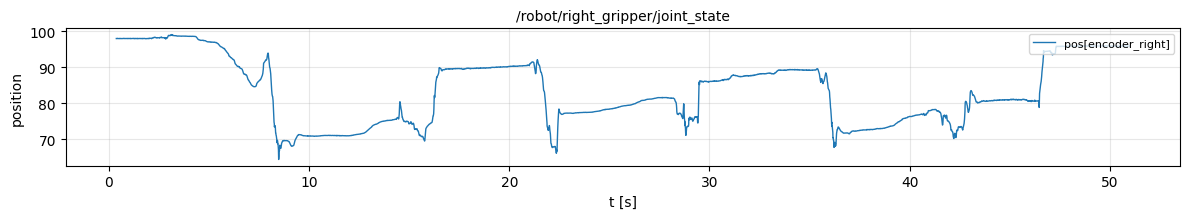

In [7]:
joint_topics = sorted([t for t, s, _, c in chs if s == 'sensor_msgs/JointState' and c > 0])
empty_joint = [t for t, s, _, c in chs if s == 'sensor_msgs/JointState' and c == 0]
print('joint topics:', joint_topics)
if empty_joint:
    print('  (empty, skipped):', empty_joint)

joint_series = {}
if joint_topics:
    with open(MCAP_PATH, 'rb') as f:
        reader = make_reader(f)
        for _, ch, msg in reader.iter_messages(topics=joint_topics):
            d = parse_joint_state(msg.data)
            joint_series.setdefault(ch.topic, []).append(d)

if joint_topics:
    fig, axes = plt.subplots(len(joint_topics), 1, figsize=(12, 2.3*len(joint_topics)), squeeze=False)
    for r, topic in enumerate(joint_topics):
        recs = joint_series[topic]
        t = np.array([r_['ts'] for r_ in recs]) - t_start
        names = recs[0]['name']
        pos = np.array([r_['position'] for r_ in recs])
        ax = axes[r, 0]
        for i, n in enumerate(names):
            ax.plot(t, pos[:, i], lw=1.0, label=f'pos[{n}]')
        if recs[0]['velocity']:
            vel = np.array([r_['velocity'] for r_ in recs])
            ax2 = ax.twinx()
            for i, n in enumerate(names):
                ax2.plot(t, vel[:, i], lw=0.8, alpha=0.6, color='tab:red', label=f'vel[{n}]')
            ax2.set_ylabel('velocity', color='tab:red', fontsize=9)
        ax.set_title(topic, fontsize=10)
        ax.set_xlabel('t [s]')
        ax.set_ylabel('position')
        ax.legend(fontsize=8, loc='upper right')
        ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print('no non-empty joint state topics')

## IMU

imu topics: ['/robot/imu/head/data', '/robot/imu/left_wrist/data', '/robot/imu/right_wrist/data']


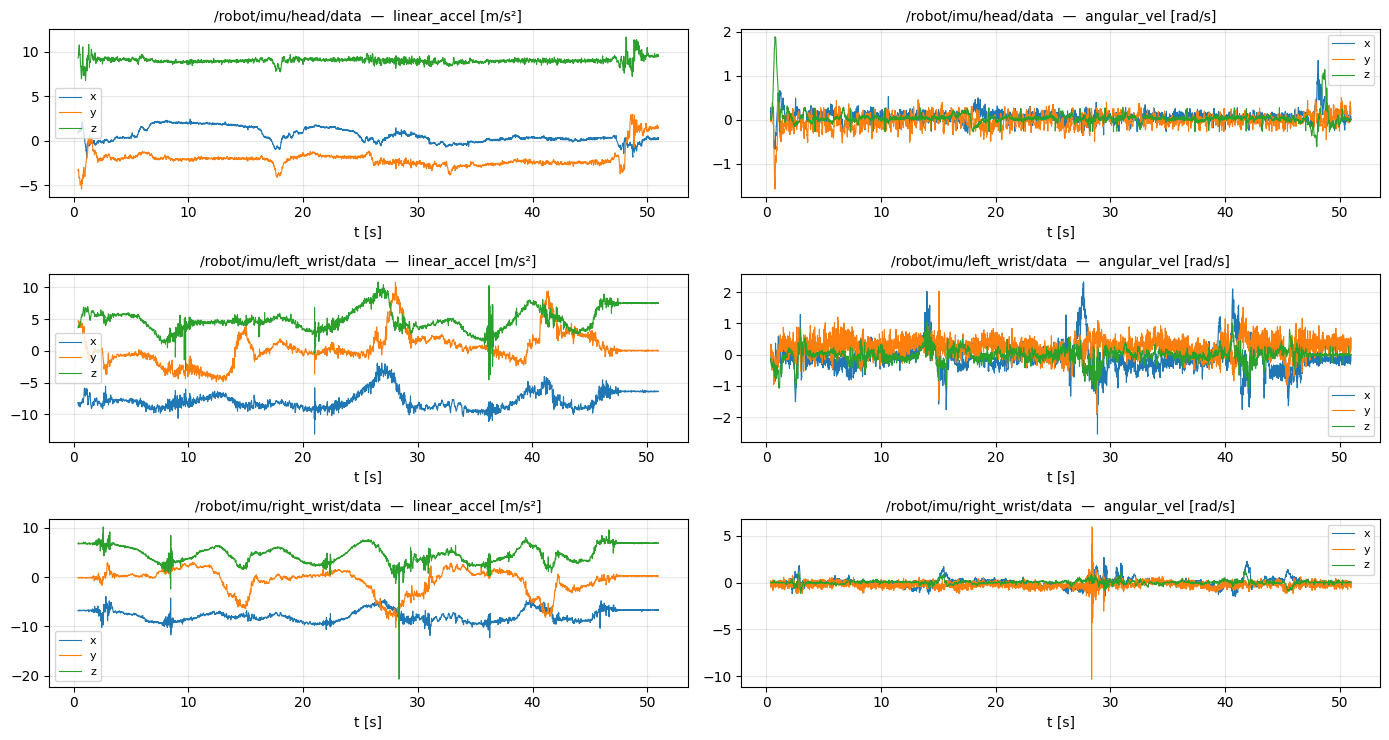

In [8]:
imu_topics = sorted([t for t, s, _, c in chs if s == 'sensor_msgs/Imu' and c > 0])
print('imu topics:', imu_topics)

imu_series = {}
if imu_topics:
    with open(MCAP_PATH, 'rb') as f:
        reader = make_reader(f)
        for _, ch, msg in reader.iter_messages(topics=imu_topics):
            d = parse_imu(msg.data)
            imu_series.setdefault(ch.topic, []).append(d)

if imu_topics:
    fig, axes = plt.subplots(len(imu_topics), 2, figsize=(14, 2.5*len(imu_topics)), squeeze=False)
    for r, topic in enumerate(imu_topics):
        recs = imu_series[topic]
        t   = np.array([x['ts'] for x in recs]) - t_start
        lin = np.array([x['lin_acc'] for x in recs])
        ang = np.array([x['ang_vel'] for x in recs])
        for i, lab in enumerate('xyz'):
            axes[r, 0].plot(t, lin[:, i], lw=0.8, label=lab)
            axes[r, 1].plot(t, ang[:, i], lw=0.8, label=lab)
        axes[r, 0].set_title(f'{topic}  —  linear_accel [m/s²]', fontsize=10)
        axes[r, 1].set_title(f'{topic}  —  angular_vel [rad/s]', fontsize=10)
        for c in (0, 1):
            axes[r, c].set_xlabel('t [s]')
            axes[r, c].legend(fontsize=8)
            axes[r, c].grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

## Tactile point clouds

For each gripper-finger stream we (1) print field layout, (2) plot per-frame aggregates (sum of each x/y/z component, mean of any extra scalar fields), (3) overlay a single "activity" curve per finger using the mean per-point vector magnitude, and (4) draw a `point_idx × time` heatmap showing where on the finger the contact pattern moves.

pointcloud topics: ['/robot/tactile/left_gripper/finger0/points', '/robot/tactile/left_gripper/finger1/points', '/robot/tactile/right_gripper/finger0/points', '/robot/tactile/right_gripper/finger1/points']
/robot/tactile/left_gripper/finger0/points
  fields: x(dt=7), y(dt=7), z(dt=7), fx(dt=7), fy(dt=7), fz(dt=7), total_fx(dt=7), total_fy(dt=7), total_fz(dt=7)
  width x height: 25 x 1   msgs: 4212   point_step: 36
/robot/tactile/left_gripper/finger1/points
  fields: x(dt=7), y(dt=7), z(dt=7), fx(dt=7), fy(dt=7), fz(dt=7), total_fx(dt=7), total_fy(dt=7), total_fz(dt=7)
  width x height: 25 x 1   msgs: 4218   point_step: 36
/robot/tactile/right_gripper/finger0/points
  fields: x(dt=7), y(dt=7), z(dt=7), fx(dt=7), fy(dt=7), fz(dt=7), total_fx(dt=7), total_fy(dt=7), total_fz(dt=7)
  width x height: 25 x 1   msgs: 4217   point_step: 36
/robot/tactile/right_gripper/finger1/points
  fields: x(dt=7), y(dt=7), z(dt=7), fx(dt=7), fy(dt=7), fz(dt=7), total_fx(dt=7), total_fy(dt=7), total_fz(dt=7)

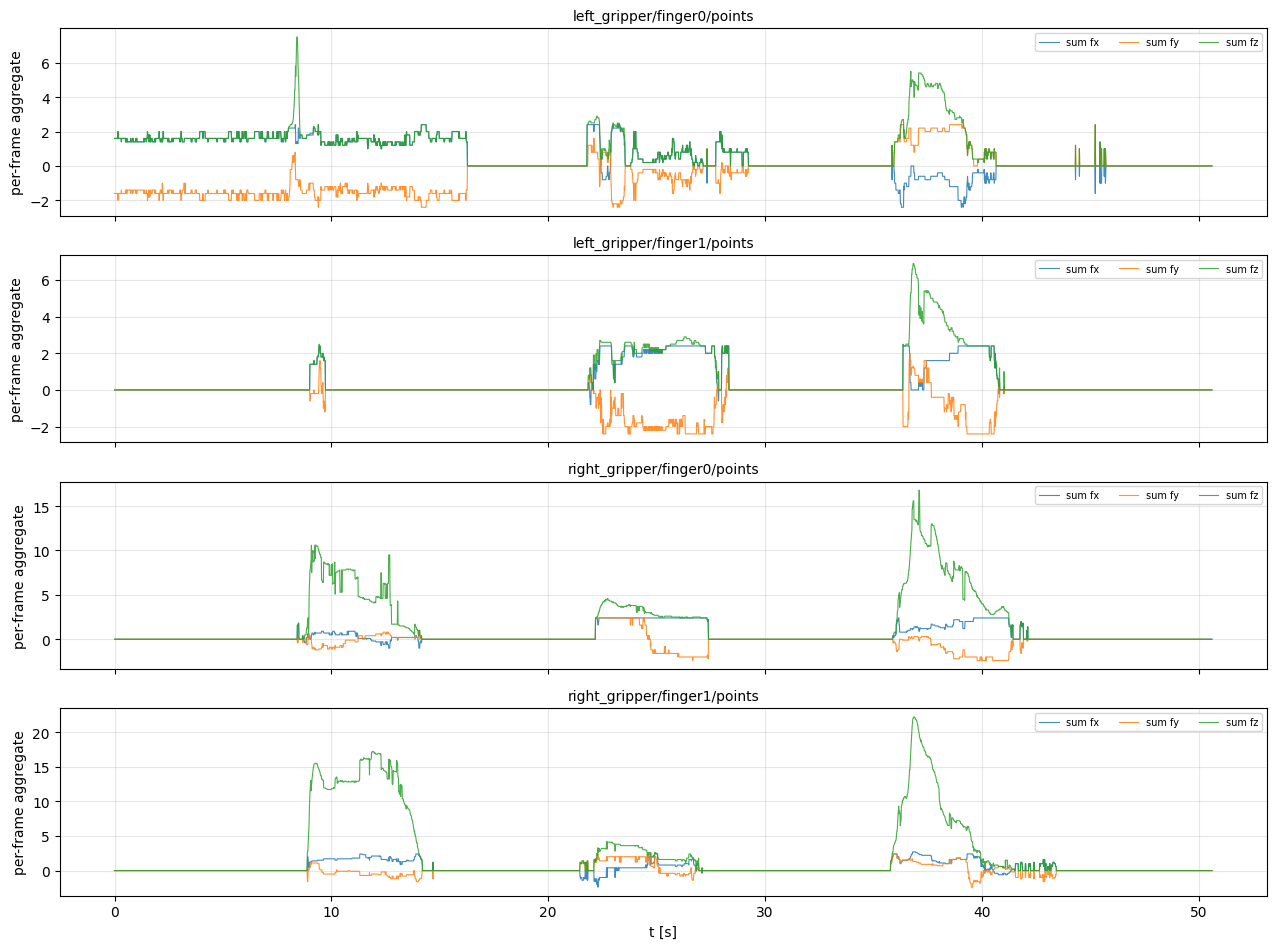

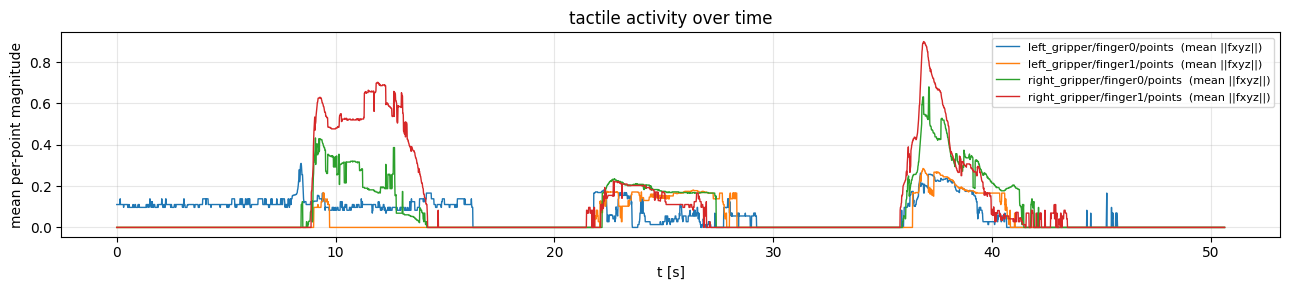

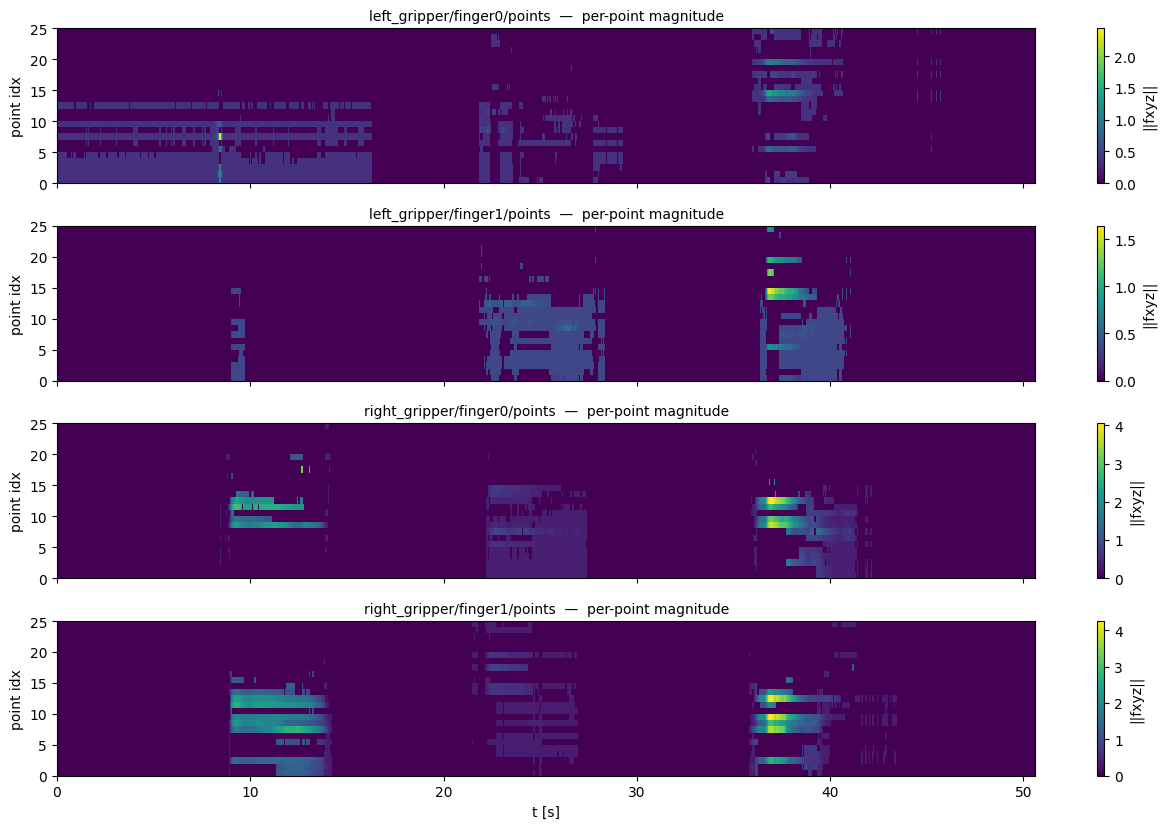

In [22]:
pc_topics = sorted([t for t, s, _, c in chs if s == 'sensor_msgs/PointCloud2' and c > 0])
print('pointcloud topics:', pc_topics)

pc_series = {}
if pc_topics:
    with open(MCAP_PATH, 'rb') as f:
        reader = make_reader(f)
        for _, ch, msg in reader.iter_messages(topics=pc_topics):
            d = parse_pointcloud_full(msg.data)
            pc_series.setdefault(ch.topic, []).append(d)

# Reuse the camera-grid t_start if it's been set; otherwise fall back to the earliest tactile timestamp.
try:
    t_start
except NameError:
    t_start = min(r['ts'] for recs in pc_series.values() for r in recs) if pc_series else 0.0

for topic in pc_topics:
    recs = pc_series[topic]
    first = recs[0]
    fs = ', '.join(f"{f['name']}(dt={f['dt']})" for f in first['fields'])
    print(f"{topic}")
    print(f"  fields: {fs}")
    print(f"  width x height: {first['width']} x {first['height']}   msgs: {len(recs)}   point_step: {first['point_step']}")

def _short(topic):
    return '/'.join(topic.strip('/').split('/')[-3:])

# Detect prefixed (x,y,z)-style vector triplets (fx/fy/fz, nx/ny/nz, ...).
# We skip:
#   * bare (x,y,z) — point position
#   * any field whose name contains an EXCLUDE_SUBSTR (e.g. 'total_fx/y/z'
#     are pre-aggregated sums, redundant with the per-point sum we compute).
POSITION_FIELDS = {'x', 'y', 'z'}
EXCLUDE_SUBSTRS = ('total',)

def _excluded(name):
    return any(sub in name for sub in EXCLUDE_SUBSTRS)

def _find_triplets(field_names):
    triplets, used = [], set()
    for f in field_names:
        if f in used or not f.endswith('x') or len(f) < 2 or _excluded(f):
            continue
        stem = f[:-1]
        tri = [stem + s for s in 'xyz']
        if all(t in field_names for t in tri):
            triplets.append((stem, tri))
            used.update(tri)
    scalars = [f for f in field_names
               if f not in used and f not in POSITION_FIELDS and not _excluded(f)]
    return triplets, scalars

if pc_topics:
    # Pre-stack each topic into (n_msgs, n_points, 3) per detected triplet.
    stacked = {}
    for topic in pc_topics:
        recs = pc_series[topic]
        field_names = [f['name'] for f in recs[0]['fields']]
        tris, scs = _find_triplets(field_names)
        ts = np.array([r['ts'] for r in recs])
        tri_arr = {}
        for stem, tri in tris:
            arr = np.stack([
                np.stack([r['points'][c].astype(np.float32) for c in tri], axis=-1)
                for r in recs
            ], axis=0)  # (n_msgs, n_points, 3)
            tri_arr[stem] = (tri, arr)
        sc_arr = {s: np.array([r['points'][s].astype(np.float64).mean() for r in recs])
                  for s in scs}
        stacked[topic] = {'ts': ts, 'triplets': tri_arr, 'scalars': sc_arr}

    has_triplet = any(s['triplets'] for s in stacked.values())
    if not has_triplet:
        print('no force-style (e.g. fx/fy/fz, nx/ny/nz) vector triplet detected — nothing to plot.')
    else:
        # ---- Plot 1: per-finger detail — sum of force components + extra scalar means over time ----
        fig, axes = plt.subplots(len(pc_topics), 1, figsize=(13, 2.4*len(pc_topics)),
                                  squeeze=False, sharex=True)
        for r, topic in enumerate(pc_topics):
            s = stacked[topic]; t = s['ts'] - t_start
            ax = axes[r, 0]
            for stem, (tri, arr) in s['triplets'].items():
                comp_sum = arr.sum(axis=1)  # (n_msgs, 3)
                for i, c in enumerate(tri):
                    ax.plot(t, comp_sum[:, i], lw=0.8, alpha=0.85, label=f'sum {c}')
            for name, v in s['scalars'].items():
                ax.plot(t, v, lw=0.8, alpha=0.85, label=f'mean({name})')
            ax.set_title(_short(topic), fontsize=10)
            ax.set_ylabel('per-frame aggregate')
            ax.legend(fontsize=7, loc='upper right', ncol=6)
            ax.grid(alpha=0.3)
        axes[-1, 0].set_xlabel('t [s]')
        plt.tight_layout(); plt.show()

        # ---- Plot 2: tactile activity — mean per-point ||triplet|| for each finger, overlaid ----
        fig, ax = plt.subplots(figsize=(13, 3))
        for topic in pc_topics:
            s = stacked[topic]
            if not s['triplets']: continue
            stem, (tri, arr) = next(iter(s['triplets'].items()))
            mag = np.linalg.norm(arr, axis=2).mean(axis=1)  # (n_msgs,)
            ax.plot(s['ts'] - t_start, mag, lw=1.0,
                    label=f'{_short(topic)}  (mean ||{stem}xyz||)')
        ax.set_xlabel('t [s]')
        ax.set_ylabel('mean per-point magnitude')
        ax.set_title('tactile activity over time')
        ax.legend(fontsize=8, loc='upper right')
        ax.grid(alpha=0.3)
        plt.tight_layout(); plt.show()

        # ---- Plot 3: per-finger heatmap — per-point magnitude vs time ----
        fig, axes = plt.subplots(len(pc_topics), 1, figsize=(13, 2.1*len(pc_topics)),
                                  squeeze=False, sharex=True)
        for r, topic in enumerate(pc_topics):
            s = stacked[topic]
            ax = axes[r, 0]
            if not s['triplets']:
                ax.set_visible(False); continue
            stem, (tri, arr) = next(iter(s['triplets'].items()))
            mag = np.linalg.norm(arr, axis=2)  # (n_msgs, n_points)
            t = s['ts'] - t_start
            im = ax.imshow(mag.T, aspect='auto', origin='lower',
                           extent=[t[0], t[-1], 0, mag.shape[1]],
                           cmap='viridis', interpolation='nearest')
            plt.colorbar(im, ax=ax, label=f'||{stem}xyz||')
            ax.set_title(f'{_short(topic)}  —  per-point magnitude', fontsize=10)
            ax.set_ylabel('point idx')
        axes[-1, 0].set_xlabel('t [s]')
        plt.tight_layout(); plt.show()

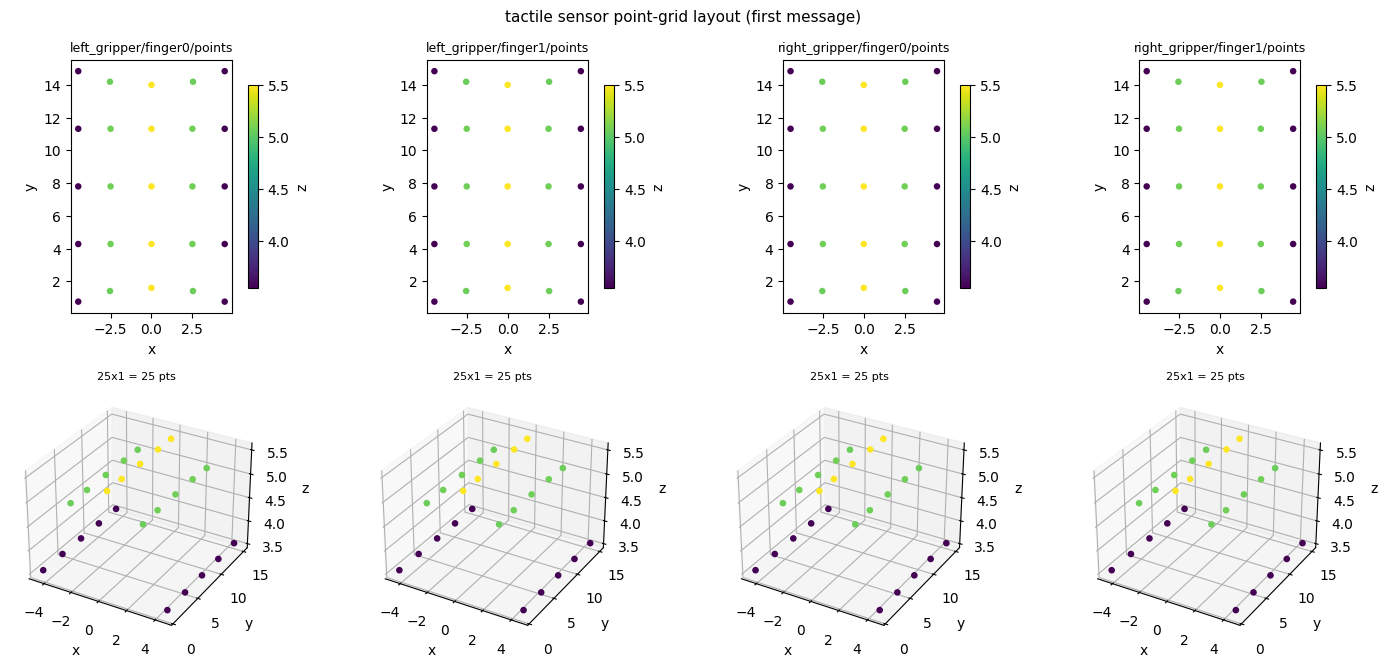

In [25]:
# Sensor point-grid layout: each tactile finger has a fixed grid of (x,y,z) sense points.
# Plot the layout from the first message of each topic — 2D scatter (x,y) coloured by z,
# plus a 3D scatter so curvature of the sensing surface is visible.
if pc_topics:
    n = len(pc_topics)
    fig = plt.figure(figsize=(3.6*n, 6.6))

    for c, topic in enumerate(pc_topics):
        rec = pc_series[topic][0]
        names = [f['name'] for f in rec['fields']]
        if not all(k in names for k in ('x', 'y', 'z')):
            continue
        x = rec['points']['x'].astype(np.float64)
        y = rec['points']['y'].astype(np.float64)
        z = rec['points']['z'].astype(np.float64)

        # Top row: 2D scatter, x vs y, coloured by z.
        ax2d = fig.add_subplot(2, n, c + 1)
        sc = ax2d.scatter(x, y, c=z, s=22, cmap='viridis', edgecolors='none')
        ax2d.set_aspect('equal')
        ax2d.set_title(_short(topic), fontsize=9)
        ax2d.set_xlabel('x'); ax2d.set_ylabel('y')
        plt.colorbar(sc, ax=ax2d, shrink=0.8, label='z')

        # Bottom row: 3D scatter.
        ax3d = fig.add_subplot(2, n, n + c + 1, projection='3d')
        ax3d.scatter(x, y, z, c=z, s=14, cmap='viridis', depthshade=False)
        ax3d.set_xlabel('x'); ax3d.set_ylabel('y'); ax3d.set_zlabel('z')
        ax3d.set_title(f'{rec["width"]}x{rec["height"]} = {rec["n_points"]} pts',
                       fontsize=8)

    fig.suptitle('tactile sensor point-grid layout (first message)', fontsize=11)
    plt.tight_layout()
    plt.show()

## Camera info

Just a quick peek at the first `CameraInfo` message for each stream — these topics appear to be sparsely populated in this recording.

In [10]:
ci_topics = sorted([t for t, s, _, _ in chs if s == 'sensor_msgs/CameraInfo'])
with open(MCAP_PATH, 'rb') as f:
    reader = make_reader(f)
    seen = set()
    for _, ch, msg in reader.iter_messages(topics=ci_topics):
        if ch.topic in seen: continue
        seen.add(ch.topic)
        raw = msg.data
        e = _endian(raw); o = 4
        ts, fid, o = _read_header(raw, o, e)
        o = _align(o, 4)
        height = struct.unpack_from(e + 'I', raw, o)[0]; o += 4
        width  = struct.unpack_from(e + 'I', raw, o)[0]; o += 4
        print(f"{ch.topic}: {width}x{height} (frame_id={fid!r})   raw_len={len(raw)} B")
        if len(seen) == len(ci_topics): break

/robot/camera/head/left/camera_info: 0x0 (frame_id='camera_head_left')   raw_len=325 B
/robot/camera/head/right/camera_info: 0x0 (frame_id='camera_head_right')   raw_len=325 B
/robot/camera/left_wrist/left/camera_info: 0x0 (frame_id='camera_left_wrist_left')   raw_len=325 B
/robot/camera/left_wrist/right/camera_info: 0x0 (frame_id='camera_left_wrist_right')   raw_len=325 B
/robot/camera/right_wrist/left/camera_info: 0x0 (frame_id='camera_right_wrist_left')   raw_len=325 B
/robot/camera/right_wrist/right/camera_info: 0x0 (frame_id='camera_right_wrist_right')   raw_len=333 B
